Loaded 1151 reviews.

Generating Sentiment Trends...


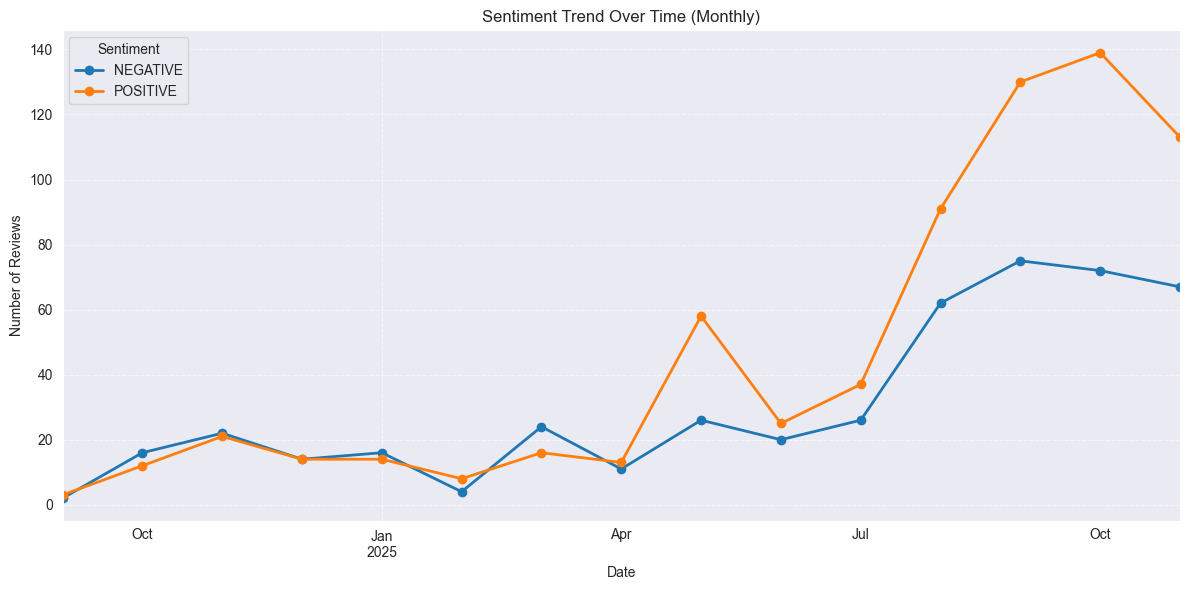

Generating Bank Comparison...


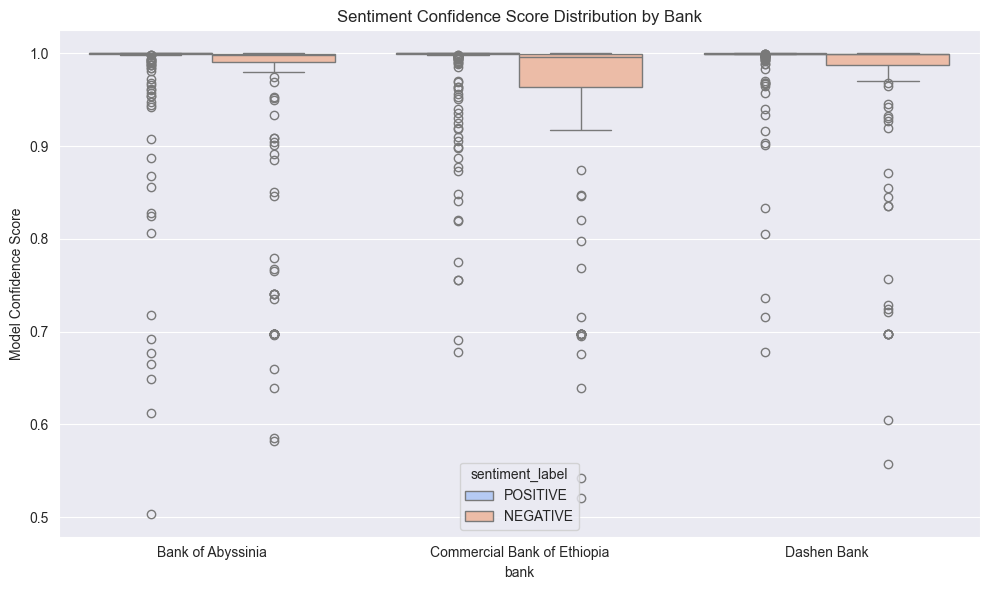

Generating Word Clouds...


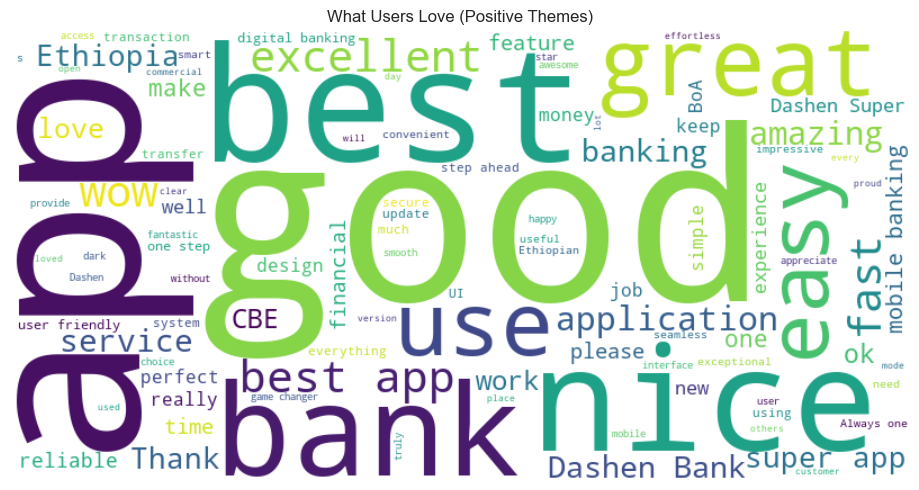

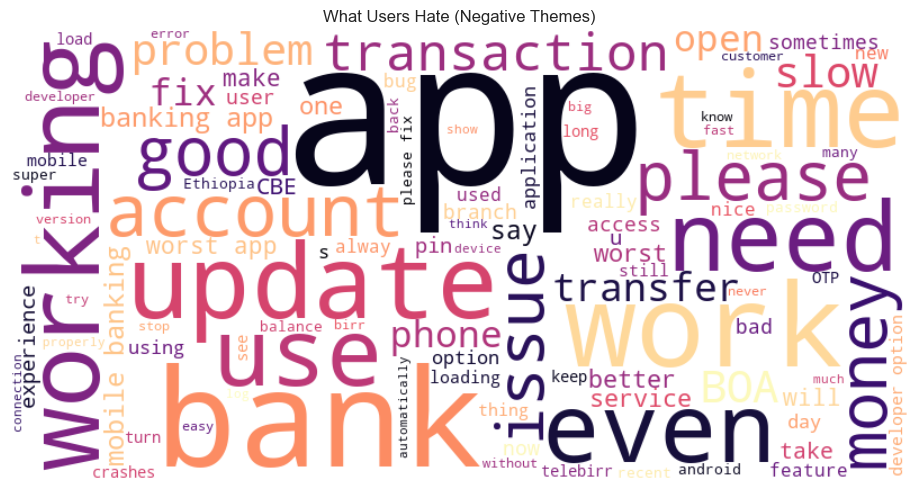

✅ All visuals saved to ../data/report_images


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

# --- CONFIGURATION ---
# We use the enriched CSV from Task 2 (or you could load from DB)
input_file = '../data/processed/reviews_with_sentiment.csv'
img_dir = '../data/report_images'
os.makedirs(img_dir, exist_ok=True)

# 1. Load Data
df = pd.read_csv(input_file)
df['date'] = pd.to_datetime(df['date']) # Ensure date format
print(f"Loaded {len(df)} reviews.")

# --- VISUALIZATION 1: SENTIMENT TRENDS (Time Series) ---
# Requirement: "Sentiment trends"
print("\nGenerating Sentiment Trends...")

# Group by Month and Sentiment
# We count how many negative vs positive reviews happened per month
df['month_year'] = df['date'].dt.to_period('M')
trend_data = df.groupby(['month_year', 'sentiment_label']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
trend_data.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())
plt.title('Sentiment Trend Over Time (Monthly)')
plt.ylabel('Number of Reviews')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(f'{img_dir}/sentiment_trend.png')
plt.show()

# --- VISUALIZATION 2: BANK COMPARISON (Box Plot) ---
# Requirement: "Compare banks"
print("Generating Bank Comparison...")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bank', y='sentiment_score', hue='sentiment_label', palette='coolwarm')
plt.title('Sentiment Confidence Score Distribution by Bank')
plt.ylabel('Model Confidence Score')
plt.tight_layout()
plt.savefig(f'{img_dir}/bank_comparison_box.png')
plt.show()

# --- VISUALIZATION 3: WORD CLOUDS ---
# Requirement: "Keyword clouds"
print("Generating Word Clouds...")

def generate_wordcloud(text_data, title, filename, color_func=None):
    text = " ".join(text_data.astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap=color_func).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'{img_dir}/{filename}')
    plt.show()

# Positive Cloud (Green tones)
pos_reviews = df[df['sentiment_label'] == 'POSITIVE']['review']
generate_wordcloud(pos_reviews, "What Users Love (Positive Themes)", "wordcloud_positive.png", 'viridis')

# Negative Cloud (Red tones)
neg_reviews = df[df['sentiment_label'] == 'NEGATIVE']['review']
generate_wordcloud(neg_reviews, "What Users Hate (Negative Themes)", "wordcloud_negative.png", 'magma')

print(f"✅ All visuals saved to {img_dir}")
